# Method development: Random Forest Regression
https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/

In [8]:
import pandas as pd
import numpy as np
import matplotlib as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

warnings.filterwarnings('ignore')

In [9]:
# Importing clean dataset
df_listings = pd.read_parquet('../data/clean_listings.parquet', engine='auto')

In [10]:
non_null_count_listings = df_listings.notnull().sum().values
nulls = df_listings.isna().sum()
types = df_listings.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})
#print(info_df)

In [11]:
# Selecting cols
cols = [
    'room_type', 'photos_count', 'superhost', 'guests', 'bedrooms', 'beds', 'baths', 
    'amenities_count', 'cleaning_fee', 'num_reviews', 'rating_overall', 'ttm_revenue',
    'country', 'city' 
]

df_listings_cols = df_listings[cols].copy()

In [12]:
# Encoding categorical columns
# TODO: change for One Hot Encoder
label_encoder = LabelEncoder()

for col in df_listings_cols.select_dtypes(include=["object"]).columns:
    df_listings_cols[col] = label_encoder.fit_transform(df_listings_cols[col].astype(str))

print(df_listings_cols.isna().sum())
print(len(df_listings_cols))
# Not the best approach, but simple solution for testing
df_listings_cols = df_listings_cols.dropna()
print(len(df_listings_cols))

room_type             0
photos_count          0
superhost             0
guests                0
bedrooms              0
beds                  0
baths                 0
amenities_count       0
cleaning_fee       1262
num_reviews           0
rating_overall        0
ttm_revenue           0
country               0
city                  0
dtype: int64
68699
67437


In [13]:
# Extracting features
feature_cols = [c for c in cols if c != 'ttm_revenue']
X = df_listings_cols[feature_cols].values
print(X)

# Extracting target variable
y = df_listings_cols['ttm_revenue'].values
print(y)

[[0 77 False ... 5.0 33 48]
 [0 34 False ... 4.76 33 48]
 [0 70 False ... 4.85 33 48]
 ...
 [0 10 False ... 4.75 32 178]
 [0 13 False ... 4.71 32 178]
 [0 15 False ... 4.61 32 178]]
<IntegerArray>
[24455, 23536, 81238, 26216, 21751, 24269,  3087, 24892,  8023, 11785,
 ...
 17279, 13266,  4228,  5954, 14598, 72773, 27137, 21790, 16405, 39956]
Length: 67437, dtype: Int64


In [14]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X)

[[0 77 False ... 5.0 33 48]
 [0 34 False ... 4.76 33 48]
 [0 70 False ... 4.85 33 48]
 ...
 [0 10 False ... 4.75 32 178]
 [0 13 False ... 4.71 32 178]
 [0 15 False ... 4.61 32 178]]


In [15]:
# Random Forest Regressor Model
regressor = RandomForestRegressor(
    n_estimators=100,  # number of decision trees in forest
    random_state=42,   # ensures reproducible results
    oob_score=True     # out-of-bag samples to estimate performance
)

regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
# Making predictions and evaluating

# Estimates the model's generalization performance
print("Out-of-Bag Score:", regressor.oob_score_)

# Predictions are made on the test set
y_pred = regressor.predict(X_test)

# Evaluates the model's performance using the Mean Squared Error (MSE) metric
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")  # same unit as ttm_revenue (likely $)

# Also useful: compare error relative to the target's scale
print(f"Mean of y_test: {y_test.mean():.2f}")
print(f"RMSE as % of mean: {(rmse / y_test.mean()) * 100:.2f}%")

# Evaluates the model's performance using the R-squared (R2) metric
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.4772854530232822
Mean Squared Error: 305001383.21649176
RMSE: 17464.29
Mean of y_test: 20864.79
RMSE as % of mean: 83.70%
R-squared: 0.45618497356558974


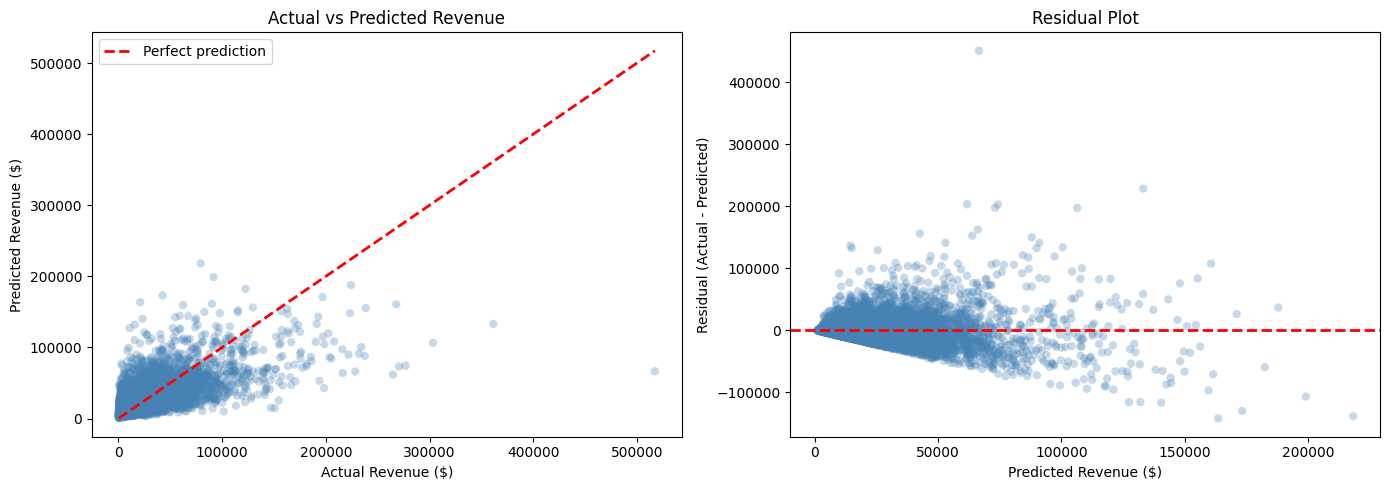

In [17]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = regressor.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Revenue ($)')
axes[0].set_ylabel('Predicted Revenue ($)')
axes[0].set_title('Actual vs Predicted Revenue')
axes[0].legend()

# --- Plot 2: Residuals ---
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='steelblue', edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Revenue ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()